**Table of contents**<a id='toc0_'></a>    
- [Graphical abstract](#toc1_)    
  - [Color palette: Okabe-Ito](#toc1_1_)    
  - [Figure](#toc1_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Graphical abstract](#toc0_)
...and specification of color palette

In [ ]:
import numpy as np
from scipy.stats import expon
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, RegularPolygon

import fluopy.figure as fi
import fluopy.miscellaneous as mi

%load_ext autoreload
%autoreload 2

saving_at = r"D:\python_output\Chapter_I\0_0_graphical_abstract"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
fluopy.figure version: 0.1.0
fluopy.miscellaneous version: 0.1.0


## <a id='toc1_1_'></a>[Color palette: Okabe-Ito](#toc0_)


In [23]:
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
blue = "#0072B2"
yellow = "#F0E442"

## <a id='toc1_2_'></a>[Figure](#toc0_)

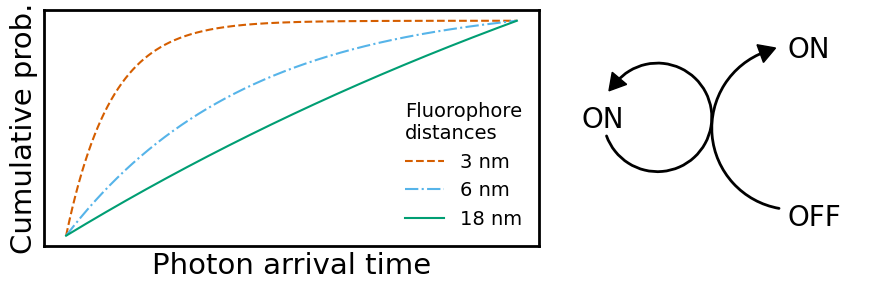

In [24]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(1, 5)
fig = plt.figure(figsize=(9, 3))
ax1 = fig.add_subplot(gs[0, 0:3])

x = np.linspace(0, 10, 1000)
nm_3 = expon.cdf(x, scale=1)
nm_6 = expon.cdf(x, scale=4)
nm_18 = expon.cdf(x, scale=20)
fi.universal_figure(
    axes=ax1,
    data=[x, nm_3 / np.max(nm_3)],
    color=red,
    label="3 nm",
    ls="--",
    fig_width=5,
)
fi.universal_figure(
    data=[x, nm_6 / np.max(nm_6)], color=sky_blue, label="6 nm", axes=ax1, ls="-."
)
fi.universal_figure(
    data=[x, nm_18 / np.max(nm_18)],
    color=green,
    label="18 nm",
    axes=ax1,
    xlabel="Photon arrival time",
    ylabel="Cumulative prob.",
    legend=True,
    xticks=[],
    yticks=[],
    legendargs={
        "frameon": False,
        "fontsize": 14,
        "title": "Fluorophore\ndistances",
        "title_fontsize": 14,
    },
)

ax2 = fig.add_subplot(gs[0, 3:])


def drawCirc(radius, centX, centY, angle, theta2, color="black", orientation="left"):
    arc = Arc(
        [centX, centY],
        radius,
        radius,
        angle=angle,
        theta1=0,
        theta2=theta2,
        capstyle="round",
        linestyle="-",
        lw=2,
        color=color,
    )
    if orientation == "left":
        endX = centX + (radius / 2) * np.cos(np.radians(theta2 + angle))
        endY = centY + (radius / 2) * np.sin(np.radians(theta2 + angle))
        polygon = RegularPolygon(
            xy=(endX, endY),
            numVertices=3,
            radius=0.02,
            orientation=np.radians(angle + theta2),
            color=color,
        )
    else:
        endX = centX + (radius / 2) * np.cos(np.radians(angle))
        endY = centY + (radius / 2) * np.sin(np.radians(angle))
        polygon = RegularPolygon(
            xy=(endX, endY),
            numVertices=3,
            radius=0.02,
            orientation=np.radians(angle + 180),
            color=color,
        )
    return polygon, arc


ax2.text(s="ON", x=0.25, y=0.5, fontsize=20)
ax2.text(s="OFF", x=0.63, y=0.32, fontsize=20)
ax2.text(s="ON", x=0.63, y=0.63, fontsize=20)
p, a = drawCirc(0.2, 0.39, 0.52, 200, 300, orientation="left")
ax2.add_patch(p)
ax2.add_patch(a)
p2, a2 = drawCirc(0.3, 0.64, 0.5, angle=110, theta2=150, orientation="right")
ax2.add_patch(p2)
ax2.add_patch(a2)
ax2.axis("off")
ax2.set_xlim(0.2, 0.8)
ax2.set_ylim(0.3, 0.7)
ax2.set_aspect(1)

fig.tight_layout()
fig.savefig(
    saving_at + r"\graphical_abstract_fig.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1,
)